In [36]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras import layers, models

In [37]:
dataset, info = tfds.load(
    'horses_or_humans',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

train_dataset, val_dataset = dataset

print(f"Информация о датасете:")
print(info)

def preprocess_image(image, label, img_size=(150, 150)):
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

train_dataset = train_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Информация о датасете:
tfds.core.DatasetInfo(
    name='horses_or_humans',
    full_name='horses_or_humans/3.0.0',
    description="""
    A large set of images of horses and humans.
    """,
    homepage='http://laurencemoroney.com/horses-or-humans-dataset',
    data_dir='C:\\Users\\Lenovo\\tensorflow_datasets\\horses_or_humans\\3.0.0',
    file_format=tfrecord,
    download_size=153.59 MiB,
    dataset_size=153.53 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=256, num_shards=1>,
        'train': <SplitInfo num_examples=1027, num_shards=2>,
    },
    citation="""@ONLINE {horses_or_humans,
    author = "Laurence Moroney",
    title = "Horses or Humans Dataset",
    month = "feb",
    year = "2019",
    url = "http

In [38]:
def create_cnn_model(input_shape=(150, 150, 3)):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.7498 - auc: 0.8446 - loss: 0.4739 - val_accuracy: 0.9219 - val_auc: 0.9501 - val_loss: 0.4543
Epoch 2/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.9192 - auc: 0.9731 - loss: 0.2118 - val_accuracy: 0.8672 - val_auc: 0.9498 - val_loss: 0.5367


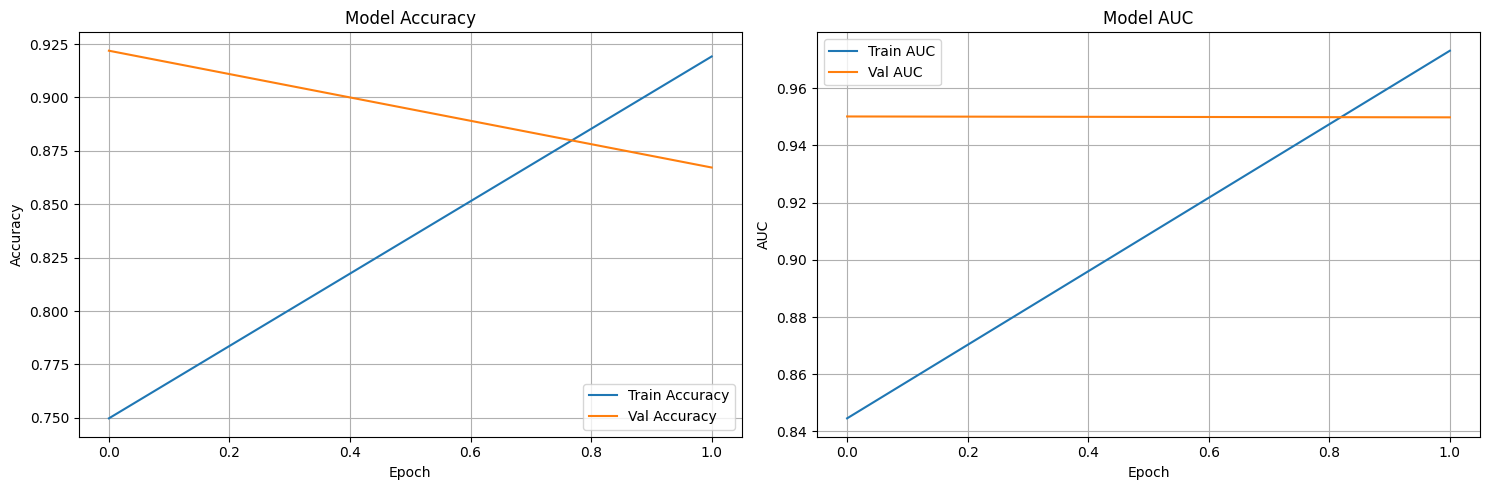


Оценка на валидационном наборе:
Validation Loss: 0.5367
Validation Accuracy: 0.8672
Validation AUC: 0.9498


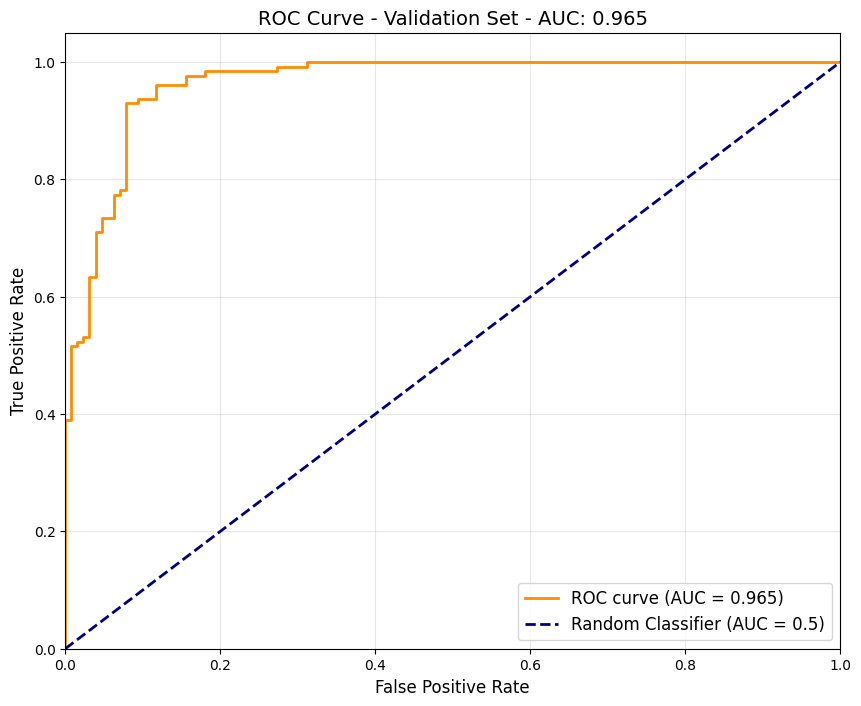

In [39]:
model = create_cnn_model()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

EPOCHS = 2
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    verbose=1
)


def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history.history['auc'], label='Train AUC')
    axes[1].plot(history.history['val_auc'], label='Val AUC')
    axes[1].set_title('Model AUC')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


def plot_roc_auc(model, dataset, title="ROC Curve"):
    y_true = []
    y_pred = []
    
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.flatten())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{title} - AUC: {roc_auc:.3f}', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return y_true, y_pred, roc_auc


print("\nОценка на валидационном наборе:")
val_loss, val_accuracy, val_auc = model.evaluate(val_dataset, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

y_true, y_pred, roc_auc = plot_roc_auc(model, val_dataset, 
                                        title="ROC Curve - Validation Set")

In [40]:
model.save('model.h5')

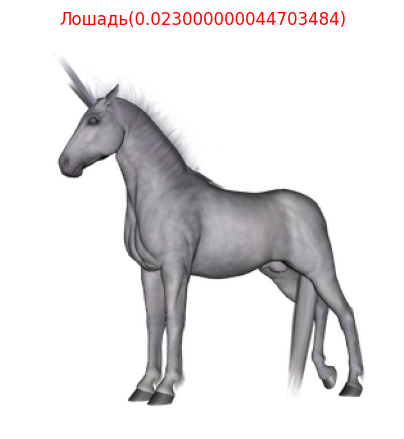

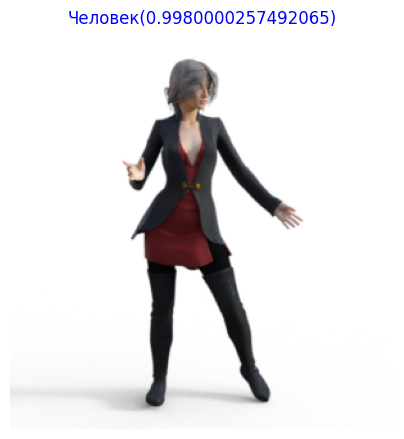

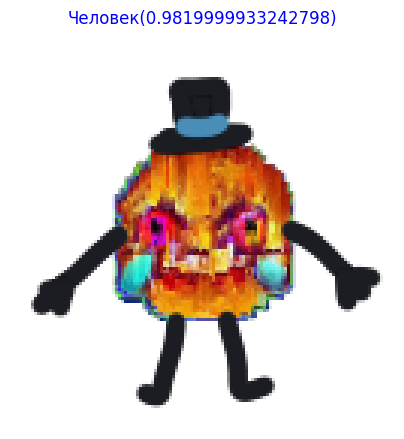

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.models import load_model

def visualize_predictions(model, img_path, img_size=(150, 150), threshold=0.5):
    
    img = Image.open(img_path)
        
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    img_array = np.array(img)
    img_array = cv2.resize(img_array, img_size)
    img_array = img_array.astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]
    predicted_class = 1 if prediction >= threshold else 0

    class_names = ['Лошадь', 'Человек']
    class_colors = ['red', 'blue']
    
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))


    ax.imshow(img)
    ax.axis('off')
    color = class_colors[predicted_class]
    pred_class = class_names[predicted_class]

    ax.set_title(pred_class + f"({prediction})", color=color, fontsize=12, pad=15)



model = load_model('model.h5')
visualize_predictions(model, "hor.png")
visualize_predictions(model, "hum.png")
visualize_predictions(model, "s.png")